# Single-Qubit Workflow: From Josephson Junction to $T_1$ and $T_2$

This notebook follows the theoretical workflow from the textbook (Chapter 13):  
**Josephson junction parameters → circuit Hamiltonian → qubit frequency and anharmonicity → decay rates → $T_1$, $T_\varphi$, $T_2$**

---

## Parameter Origin Guide

Every parameter is tagged with one of four origins:

| Tag | Meaning | Example |
|---|---|---|
| `[MATERIAL]` | Fixed by choice of superconductor. Cannot be changed by redesigning the chip. Comes from BCS theory or bulk measurement. | $\Delta_{sc}$ |
| `[GEOMETRY]` | Set by the fabrication mask. You draw it, you choose it. Change it by redesigning the chip. | $R_N$, $C_\text{shunt}$, $C_c$, $f_r$ |
| `[OPERATING]` | Not fixed at fabrication. Tuned during the experiment. | $T_\text{fridge}$, $\kappa$, $\Phi/\Phi_0$ |
| `[MEASURED]` | Cannot be reliably predicted from first principles. Extracted from a calibration measurement on the actual device. | $\tan\delta$, $x_\text{qp}$, $A_\Phi$ |

Some parameters carry two tags — e.g. $\tan\delta$ is `[MATERIAL]` (it is a property of the oxide chemistry) but also `[MEASURED]` (it must be extracted from a resonator $Q_i$ measurement, not computed).

**Key insight about $E_J$ and $E_C$:**
- $E_C = e^2/2C_\Sigma$ is **purely geometry** — determined by capacitor pad dimensions.
- $E_J = \pi\hbar\Delta_{sc}/4e^2 R_N$ is **material + geometry** — $\Delta_{sc}$ is fixed by the superconductor (BCS theory), but $R_N$ is set by junction area on the mask.
- $\Delta_{sc}$ is the most fundamental theoretical input: it sets the Cooper-pair binding energy, the maximum photon frequency the junction can absorb without breaking pairs, and enters the Ambegaokar–Baratoff formula directly.

---
## Structure
1. Physical constants  
2. All device parameters (tagged by origin)  
3. Junction → $E_J$, $E_C$  
4. Transmon → $\omega_{01}$, $\alpha$  
5. Resonator → $g$, $\chi$  
6. $T_1$ decay channels  
7. Dephasing → $T_\varphi$  
8. $T_2$ and diagnosis  
9. Summary dashboard  
10. Numerical summary  
11. Sensitivity analysis  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# Figures are saved in the same folder as this notebook.
OUTDIR = os.getcwd()

plt.rcParams.update({'font.size':12,'axes.labelsize':13,
                     'axes.titlesize':14,'figure.dpi':110,'lines.linewidth':2})
print(f'Output directory: {OUTDIR}')

Output directory: /Users/farukakbar/Downloads/files


---
## 1. Physical Constants

In [2]:
hbar = 1.0545718e-34   # J·s
h    = 2*np.pi*hbar
e    = 1.6021766e-19   # C
kB   = 1.3806503e-23   # J/K
Phi0 = h/(2*e)         # Wb  flux quantum
print(f'hbar={hbar:.3e}, e={e:.3e}, Phi0={Phi0:.3e}')

hbar=1.055e-34, e=1.602e-19, Phi0=2.068e-15


---
## 2. Device Parameters

In [3]:
# ════════════════════════════════════════════════════════════
# A. MATERIAL — fixed by choice of superconductor
# ════════════════════════════════════════════════════════════

# [MATERIAL] Superconducting energy gap
# From BCS theory: Delta_sc = 1.764 * kB * Tc
# For Al: Tc ≈ 1.1 K  →  Delta_sc ≈ 170 μeV
# For Nb: Tc ≈ 9.2 K  →  Delta_sc ≈ 1500 μeV
# For Ta: Tc ≈ 4.5 K  →  Delta_sc ≈ 700 μeV
# Delta_sc determines:
#   (a) E_J via Ambegaokar-Baratoff
#   (b) the quasiparticle gap (photons below 2*Delta_sc/hbar cannot break pairs)
#   (c) the quasiparticle contribution to T1
Delta_sc = 170e-6 * e   # J  (170 μeV for aluminium)

# [MATERIAL][MEASURED] Surface oxide loss tangent
# tan(delta) = epsilon'' / epsilon' = energy lost per radian / energy stored
# This is a property of the amorphous oxide on the metal surface (AlOx, NbOx).
# It cannot be computed reliably — measure from high-Q resonator:
#   tan(delta) ≈ 1/Q_i   at single-photon power
# Typical: Al on Si ~1e-3,  Ta on Si ~3e-4,  Nb on sapphire ~1e-4
tan_delta = 1e-3

# ════════════════════════════════════════════════════════════
# B. GEOMETRY — set by the fabrication mask
# ════════════════════════════════════════════════════════════

# [GEOMETRY] Normal-state junction resistance
# Set by junction area x barrier thickness.
# Larger area → smaller R_N → larger I_c → larger E_J.
# Measured at room temperature before cooldown.
R_N = 10000.0         # Ω  (larger R_N → smaller I_c → balanced T1 channels)

# [GEOMETRY] Junction self-capacitance (from junction area)
C_J = 5e-15           # F  (5 fF)

# [GEOMETRY] Shunting capacitor
# Large metal pad in parallel with junction.
# Larger C_shunt → smaller E_C → larger E_J/E_C → better charge-noise immunity
# but smaller anharmonicity. Typical: 50–100 fF.
C_shunt = 70e-15      # F  (70 fF)

# [GEOMETRY] Resonator frequency
# Set by physical length of the microwave resonator (lambda/4 or lambda/2).
# Typically 500 MHz to 2 GHz above qubit frequency.
f_r = 8.5e9           # Hz  (8.5 GHz: 2 GHz above qubit → dispersive limit OK)

# [GEOMETRY] Qubit-resonator coupling capacitor
# Gap between qubit pad and resonator. Smaller gap → larger C_c → larger g.
C_c = 2e-15           # F  (2 fF, smaller → g/|Δ_qr| << 1)

# [GEOMETRY] Resonator capacitance
C_r = 200e-15         # F  (200 fF)

# [GEOMETRY] Participation ratio of electric field in lossy surface oxide
# p_surf = integral_surface(eps|E|^2 dV) / integral_all(eps|E|^2 dV)
# Computed from FEM simulation. Depends on capacitor pad shape.
# Typical: 1e-4 to 1e-3.
p_surf = 3e-4

# ════════════════════════════════════════════════════════════
# C. OPERATING — set or tuned during the experiment
# ════════════════════════════════════════════════════════════

# [OPERATING] Fridge temperature
T_fridge = 0.015      # K  (15 mK)

# [OPERATING] Resonator linewidth (photon decay rate out to the amplifier chain)
# Larger kappa → faster readout but stronger Purcell decay of the qubit.
# This is the central readout-speed vs T1 trade-off.
kappa = 2*np.pi*10e6  # rad/s  (10 MHz)

# [OPERATING] Flux bias point (for SQUID-based transmon)
# At Phi=0 (sweet spot): maximum E_J, minimum flux sensitivity.
# Set to 0 for a simple (non-SQUID) junction transmon.
flux_bias_fraction = 0.05   # Phi/Phi_0

# [OPERATING] Purcell filter
use_purcell_filter = False
kappa_filter = 2*np.pi*50e6  # rad/s  filter bandwidth

# ════════════════════════════════════════════════════════════
# D. MEASURED — extracted from calibration on the device
# ════════════════════════════════════════════════════════════

# [MEASURED] Non-equilibrium quasiparticle density
# Inferred from T1 after subtracting Purcell and TLS contributions.
# Caused by infrared radiation, cosmic rays, substrate phonons.
x_qp = 1e-8   # state-of-the-art with good IR shielding

# [MEASURED] 1/f flux noise amplitude
# S_Phi(f) = A_Phi^2 / f  (power spectral density)
# Measured from CPMG noise spectroscopy. Typical: ~1 μΦ₀/√Hz.
A_flux = 1e-6*Phi0   # Wb/√Hz

print('Parameters set:')
print(f'  [MATERIAL]  Delta_sc = {Delta_sc/e*1e6:.0f} μeV,  tan_delta = {tan_delta:.1e}')
print(f'  [GEOMETRY]  R_N={R_N:.0f}Ω, C_shunt={C_shunt*1e15:.0f}fF, f_r={f_r*1e-9:.1f}GHz')
print(f'  [OPERATING] T_fridge={T_fridge*1e3:.0f}mK, kappa/(2pi)={kappa/(2*np.pi)*1e-6:.0f}MHz')
print(f'  [MEASURED]  x_qp={x_qp:.1e}, A_flux={A_flux/Phi0*1e6:.1f}μΦ₀/√Hz')

Parameters set:
  [MATERIAL]  Delta_sc = 170 μeV,  tan_delta = 1.0e-03
  [GEOMETRY]  R_N=10000Ω, C_shunt=70fF, f_r=8.5GHz
  [OPERATING] T_fridge=15mK, kappa/(2pi)=10MHz
  [MEASURED]  x_qp=1.0e-08, A_flux=1.0μΦ₀/√Hz


---
## 3. Junction → $E_J$, $E_C$

**Ambegaokar–Baratoff**: $I_c = \frac{\pi\Delta_{sc}}{2eR_N}\tanh\!\left(\frac{\Delta_{sc}}{2k_BT}\right)$, then $E_J = \hbar I_c/2e$.

$E_C = e^2/2C_\Sigma$ is purely geometric.

In [4]:
tanh_factor = np.tanh(Delta_sc/(2*kB*T_fridge))
I_c   = (np.pi*Delta_sc)/(2*e*R_N)*tanh_factor
E_J   = hbar*I_c/(2*e)
E_J_GHz = E_J/h*1e-9

C_Sigma = C_J + C_shunt
E_C   = e**2/(2*C_Sigma)
E_C_GHz = E_C/h*1e-9
EJ_over_EC = E_J/E_C

print(f'tanh factor = {tanh_factor:.6f}  (≈1 at 15 mK)')
print(f'I_c         = {I_c*1e9:.2f} nA')
print(f'E_J/(2π)    = {E_J_GHz:.2f} GHz   [MATERIAL via Δ_sc + GEOMETRY via R_N]')
print(f'E_C/(2π)    = {E_C_GHz*1e3:.2f} MHz   [GEOMETRY via C_shunt]')
print(f'E_J/E_C     = {EJ_over_EC:.1f}      (target: 50–100)')
if EJ_over_EC < 20:   print('⚠  Charge qubit regime!')
elif EJ_over_EC > 200: print('⚠  Anharmonicity too small!')
else:                  print('✓  Transmon regime')

tanh factor = 1.000000  (≈1 at 15 mK)
I_c         = 26.70 nA
E_J/(2π)    = 13.26 GHz   [MATERIAL via Δ_sc + GEOMETRY via R_N]
E_C/(2π)    = 258.27 MHz   [GEOMETRY via C_shunt]
E_J/E_C     = 51.4      (target: 50–100)
✓  Transmon regime


---
## 4. Transmon Spectrum → $\omega_{01}$, $\alpha$

$$\omega_{01} = \frac{\sqrt{8E_JE_C}-E_C}{\hbar}, \qquad \alpha = -\frac{E_C}{\hbar}$$

In [5]:
omega_01  = (np.sqrt(8*E_J*E_C) - E_C)/hbar
f_01      = omega_01/(2*np.pi)
alpha     = -E_C/hbar
alpha_MHz = alpha/(2*np.pi)*1e-6
charge_suppression = np.exp(-np.sqrt(8*EJ_over_EC))

print(f'f_01      = {f_01*1e-9:.4f} GHz')
print(f'α/(2π)    = {alpha_MHz:.1f} MHz  (anharmonicity, always negative)')
print(f'Charge noise suppression = {charge_suppression:.2e}')
print()
print('Context:')
print(f'  f_01= {f_01*1e-9:.3f} GHz is correct for E_J/E_C={EJ_over_EC:.0f}.')
print(f'  α = E_C/h = {abs(alpha_MHz):.0f} MHz sets the gate speed limit:')
print(f'    pulses must be spectrally narrower than |α|, so gate time >> {1/abs(alpha)*1e9:.1f} ns.')
print(f'  Charge suppression {charge_suppression:.1e}: at E_J/E_C={EJ_over_EC:.0f},')
print(f'    charge noise shifts f_01 by only ~{charge_suppression*f_01*1e-3:.2f} kHz — negligible.')
print(f'    This exponential suppression is the whole point of the transmon design.')
if abs(alpha_MHz) < 100:
    print('⚠  |α| < 100 MHz — gate speed severely constrained')

f_01      = 4.9766 GHz
α/(2π)    = -258.3 MHz  (anharmonicity, always negative)
Charge noise suppression = 1.58e-09

Context:
  f_01= 4.977 GHz is correct for E_J/E_C=51.
  α = E_C/h = 258 MHz sets the gate speed limit:
    pulses must be spectrally narrower than |α|, so gate time >> 0.6 ns.
  Charge suppression 1.6e-09: at E_J/E_C=51,
    charge noise shifts f_01 by only ~0.01 kHz — negligible.
    This exponential suppression is the whole point of the transmon design.


---
## 5. Resonator → $g$, $\chi$

$$g = \frac{C_c}{2}\sqrt{\frac{\omega_{01}\omega_r}{C_\Sigma C_r}}, \qquad \chi = \frac{g^2}{\Delta_{qr}}$$

In [6]:
omega_r  = 2*np.pi*f_r
Delta_qr = omega_01 - omega_r
g        = (C_c/2)*np.sqrt(omega_01*omega_r/(C_Sigma*C_r))
chi      = g**2/Delta_qr
n_th     = 1/(np.exp(hbar*omega_r/(kB*T_fridge))-1)

print(f'Δ_qr/(2π) = {Delta_qr/(2*np.pi)*1e-9:.3f} GHz')
print(f'g/(2π)    = {g/(2*np.pi)*1e-6:.1f} MHz   [GEOMETRY via C_c, C_r]')
print(f'χ/(2π)    = {chi/(2*np.pi)*1e-6:.2f} MHz')
print(f'κ/(2π)    = {kappa/(2*np.pi)*1e-6:.1f} MHz   [OPERATING]')
print(f'g/|Δ_qr|  = {abs(g/Delta_qr):.3f}  (dispersive limit: << 1)')
print(f'|χ|/κ     = {abs(chi/kappa):.3f}  (resolved readout: > 0.5)')
print(f'n_th      = {n_th:.2e} photons at {T_fridge*1e3:.0f} mK')
if abs(g/Delta_qr) > 0.1: print('⚠  Dispersive approximation breaking down!')
else: print('✓  Dispersive limit satisfied')

Δ_qr/(2π) = -3.523 GHz
g/(2π)    = 53.1 MHz   [GEOMETRY via C_c, C_r]
χ/(2π)    = -0.80 MHz
κ/(2π)    = 10.0 MHz   [OPERATING]
g/|Δ_qr|  = 0.015  (dispersive limit: << 1)
|χ|/κ     = 0.080  (resolved readout: > 0.5)
n_th      = 1.55e-12 photons at 15 mK
✓  Dispersive limit satisfied


---
## 6. $T_1$ Decay Channels

$1/T_1 = \Gamma_P + \Gamma_\text{TLS} + \Gamma_\text{qp}$

In [7]:
# Purcell: [GEOMETRY+OPERATING]
Gamma_P = (g/Delta_qr)**2 * kappa
if use_purcell_filter:
    Gamma_P *= (kappa_filter/Delta_qr)**2

# TLS: [GEOMETRY via p_surf] + [MATERIAL/MEASURED via tan_delta]
Gamma_TLS = p_surf * omega_01 * tan_delta

# Quasiparticles: [MATERIAL via Delta_sc, E_J] + [MEASURED via x_qp]
Gamma_qp = (8*E_J/(np.pi*hbar))*np.sqrt(2*Delta_sc/(hbar*omega_01))*x_qp

Gamma_1 = Gamma_P + Gamma_TLS + Gamma_qp
T1 = 1/Gamma_1
channels = {'Purcell': Gamma_P, 'TLS': Gamma_TLS, 'Quasiparticles': Gamma_qp}
dominant = max(channels, key=channels.get)

for name, G in channels.items():
    print(f'{name:18s}: Γ/(2π)={G/(2*np.pi)*1e-3:8.3f} kHz  T1={1/G*1e6:8.1f} μs  ({G/Gamma_1*100:.1f}%)')
print(f'────────────────────────────────────────────────────')
print(f'TOTAL           : Γ/(2π)={Gamma_1/(2*np.pi)*1e-3:8.3f} kHz  T1={T1*1e6:8.2f} μs')
print(f'Dominant channel: {dominant}')

Purcell           : Γ/(2π)=   2.272 kHz  T1=    70.1 μs  (44.2%)
TLS               : Γ/(2π)=   1.493 kHz  T1=   106.6 μs  (29.1%)
Quasiparticles    : Γ/(2π)=   1.373 kHz  T1=   115.9 μs  (26.7%)
────────────────────────────────────────────────────
TOTAL           : Γ/(2π)=   5.137 kHz  T1=   30.98 μs
Dominant channel: Purcell


---
## 7. Dephasing → $T_\varphi$

$1/T_\varphi = \Gamma_\phi^{1/f} + \Gamma_\phi^\text{photon}$

In [8]:
# Flux sensitivity at operating point  [GEOMETRY+OPERATING]
dEJ_dPhi    = -np.pi*E_J*np.sin(np.pi*flux_bias_fraction)/Phi0
domega_dEJ  = np.sqrt(2*E_C/E_J)/(2*hbar)
domega_dPhi = domega_dEJ*dEJ_dPhi

# 1/f flux noise dephasing  [MEASURED via A_flux]
Gamma_phi_flux   = abs(domega_dPhi)*A_flux*np.sqrt(2*np.log(2))

# Photon shot noise dephasing  [OPERATING via kappa, n_th]
Gamma_phi_photon = 8*chi**2*n_th/kappa

Gamma_phi = Gamma_phi_flux + Gamma_phi_photon
T_phi = 1/Gamma_phi if Gamma_phi > 0 else np.inf

# Convert rad/s/Wb  →  GHz/Φ₀ for display
# domega_dPhi is in rad/s/Wb; multiply by Phi0 to get rad/s/Phi0;
# divide by 2π×1e9 to get GHz/Phi0
dfreq_dPhi0 = domega_dPhi / (2*np.pi*1e9) * Phi0   # GHz/Phi0

print(f'dω/dΦ          = {dfreq_dPhi0:.4f} GHz/Φ₀   (at Φ/Φ₀={flux_bias_fraction})')
print(f'Γ_φ^(1/f)/(2π) = {Gamma_phi_flux/(2*np.pi)*1e-3:.4f} kHz   [MEASURED noise]')
print(f'Γ_φ^photon/(2π)= {Gamma_phi_photon/(2*np.pi)*1e-3:.4f} kHz   [OPERATING kappa,T]')
print(f'T_φ (total)    = {T_phi*1e6:.1f} μs')

dω/dΦ          = -0.6432 GHz/Φ₀   (at Φ/Φ₀=0.05)
Γ_φ^(1/f)/(2π) = 0.7573 kHz   [MEASURED noise]
Γ_φ^photon/(2π)= 0.0000 kHz   [OPERATING kappa,T]
T_φ (total)    = 210.2 μs


---
## 8. $T_2$ and Diagnosis

In [9]:
Gamma_2 = Gamma_1/2 + Gamma_phi
T2      = 1/Gamma_2
T2_max  = 2*T1

print(f'T₁     = {T1*1e6:.2f} μs')
print(f'T_φ    = {T_phi*1e6:.2f} μs')
print(f'T₂     = {T2*1e6:.2f} μs')
print(f'2T₁    = {T2_max*1e6:.2f} μs  (T₂ upper bound)')
print(f'T₂/2T₁ = {T2/T2_max:.3f}')

r = T2/T2_max
print(f'\nDiagnosis:')
if r > 0.95:
    print('→ T₁-LIMITED. T_φ ≫ T₁. Focus entirely on T₁ channels.')
elif r > 0.5:
    print('→ MIXED. Both T₁ and T_φ contribute. Improve both.')
else:
    print('→ DEPHASING-LIMITED. T_φ ≪ 2T₁. Focus on flux noise or photon noise.')

advice = {'Purcell':  'Purcell filter or increase |Δ_qr|',
          'TLS':      'Ta/Nb film; HF etch; reduce p_surf',
          'Quasiparticles': 'IR shielding; phonon traps'}
print(f'→ T₁ bottleneck: {dominant}. Fix: {advice[dominant]}')

T₁     = 30.98 μs
T_φ    = 210.17 μs
T₂     = 47.85 μs
2T₁    = 61.96 μs  (T₂ upper bound)
T₂/2T₁ = 0.772

Diagnosis:
→ MIXED. Both T₁ and T_φ contribute. Improve both.
→ T₁ bottleneck: Purcell. Fix: Purcell filter or increase |Δ_qr|


---
## 9. Summary Dashboard

/var/folders/h1/b45548ds3lv7tbbh8tkgxw_w0000gn/T/ipykernel_2718/470841666.py:65: RuntimeWarning: invalid value encountered in sqrt
  cross_idx = np.argmin(np.abs(np.array([((C_c/2)*np.sqrt(((ratio_range[k]*E_C*np.sqrt(8*ratio_range[k]*E_C)-E_C)/hbar)*omega_r/(C_Sigma*C_r))) for k in range(len(ratio_range))])))  # rough


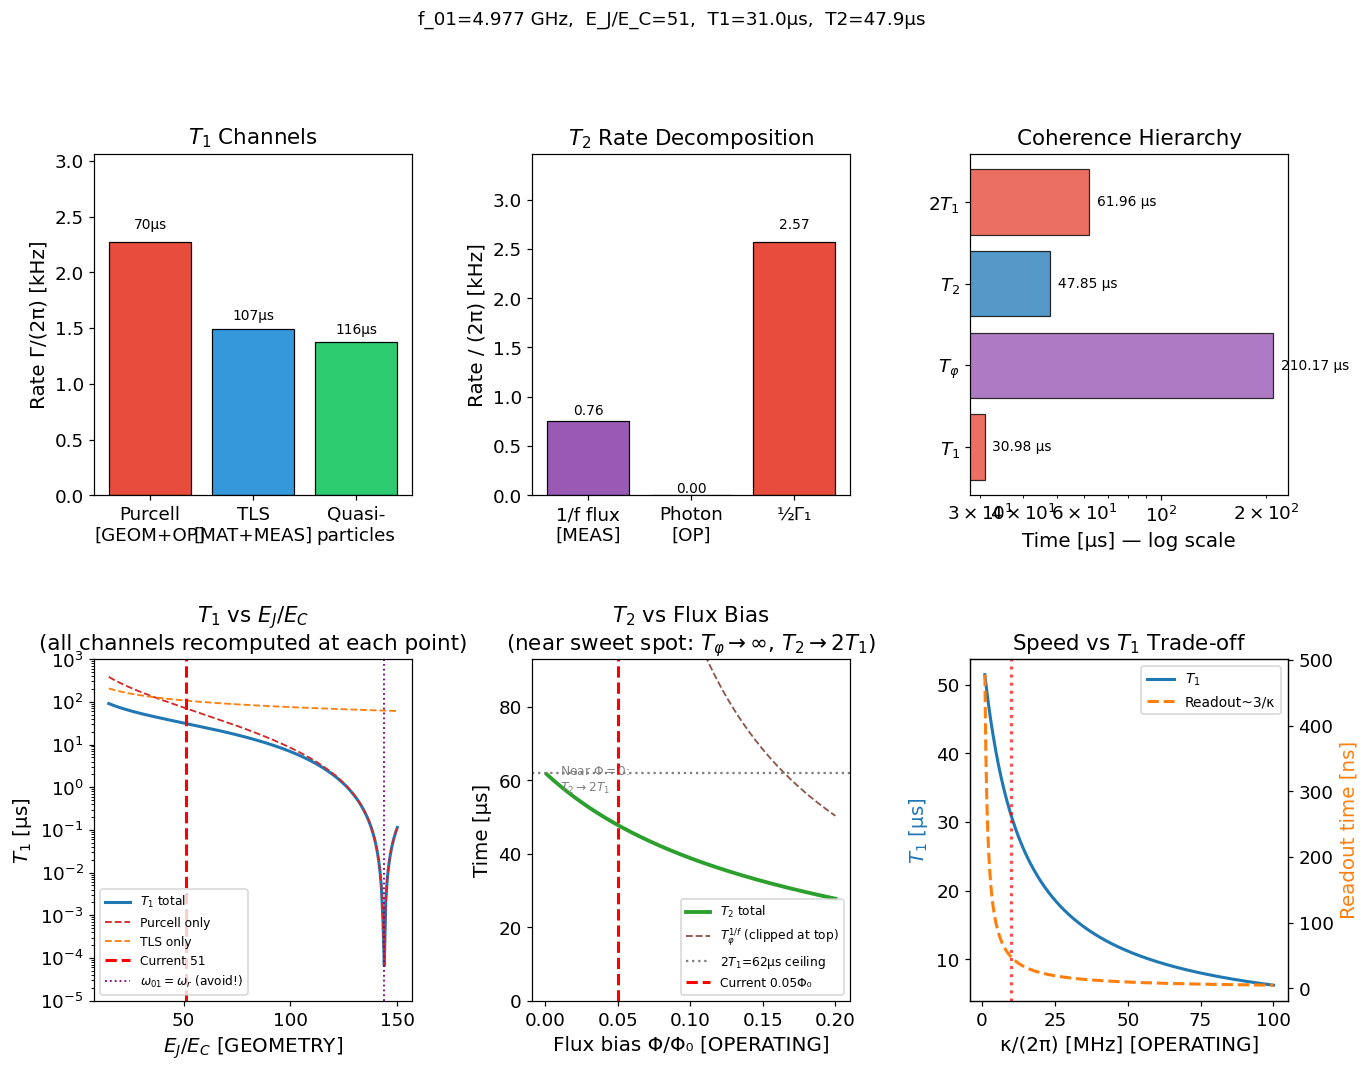

Saved: /Users/farukakbar/Downloads/files/single_qubit_summary.png


In [10]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# Panel 1: T1 channels
ax1 = fig.add_subplot(gs[0,0])
labs = ['Purcell\n[GEOM+OP]','TLS\n[MAT+MEAS]','Quasi-\nparticles']
rats = [Gamma_P, Gamma_TLS, Gamma_qp]
cols = ['#e74c3c','#3498db','#2ecc71']
bars = ax1.bar(labs,[r/(2*np.pi)*1e-3 for r in rats],color=cols,edgecolor='k',lw=0.8)
ax1.set_ylabel('Rate Γ/(2π) [kHz]'); ax1.set_title('$T_1$ Channels')
for b,r in zip(bars,rats):
    ax1.text(b.get_x()+b.get_width()/2,b.get_height()*1.04,f'{1/r*1e6:.0f}μs',
             ha='center',va='bottom',fontsize=9)
ax1.set_ylim(0,max(r/(2*np.pi)*1e-3 for r in rats)*1.35)

# Panel 2: T2 rate decomposition
ax2 = fig.add_subplot(gs[0,1])
labs2=['1/f flux\n[MEAS]','Photon\n[OP]','½Γ₁']
rats2=[Gamma_phi_flux,Gamma_phi_photon,Gamma_1/2]
cols2=['#9b59b6','#f39c12','#e74c3c']
bars2=ax2.bar(labs2,[r/(2*np.pi)*1e-3 for r in rats2],color=cols2,edgecolor='k',lw=0.8)
ax2.set_ylabel('Rate / (2π) [kHz]'); ax2.set_title('$T_2$ Rate Decomposition')
ax2.set_ylim(0,max(r/(2*np.pi)*1e-3 for r in rats2)*1.35)
for b,r in zip(bars2,rats2):
    ax2.text(b.get_x()+b.get_width()/2,b.get_height()*1.04,f'{r/(2*np.pi)*1e-3:.2f}',
             ha='center',va='bottom',fontsize=9)

# Panel 3: Coherence hierarchy — log scale to handle T1 << T_phi
ax3 = fig.add_subplot(gs[0,2])
tdict={'$T_1$':T1*1e6,'$T_\\varphi$':T_phi*1e6,'$T_2$':T2*1e6,'$2T_1$':T2_max*1e6}
cols3=['#e74c3c','#9b59b6','#2980b9','#e74c3c']
bars3=ax3.barh(list(tdict.keys()),list(tdict.values()),color=cols3,alpha=0.8,edgecolor='k',lw=0.8)
ax3.set_xlabel('Time [μs] — log scale'); ax3.set_title('Coherence Hierarchy')
ax3.set_xscale('log')
for b,(k,v) in zip(bars3,tdict.items()):
    ax3.text(v*1.05,b.get_y()+b.get_height()/2,f'{v:.2f} μs',va='center',fontsize=9)

# Panel 4: T1 vs E_J/E_C
# Each point is a FULLY self-consistent device: varying R_N (hence E_J)
# while keeping E_C fixed. All derived quantities (omega_01, g, Delta_qr)
# are recomputed at each point — not held at baseline values.
ax4 = fig.add_subplot(gs[1,0])
ratio_range = np.linspace(15, 150, 200)
# Correct inversion of Ambegaokar-Baratoff:
# E_J = pi*hbar*Delta_sc/(4*e^2*R_N)  =>  R_N = pi*hbar*Delta_sc/(4*e^2*E_J)
EJ_s  = ratio_range * E_C                      # target E_J at each ratio
RN_s  = np.pi*hbar*Delta_sc / (4*e**2 * EJ_s)  # R_N that gives each E_J/E_C
T1_P_s, T1_TLS_s, T1_QP_s = [], [], []
for rn in RN_s:
    ej_  = np.pi*hbar*Delta_sc/(4*e**2*rn)  # Ambegaokar-Baratoff directly
    om_  = (np.sqrt(8*ej_*E_C) - E_C)/hbar       # recomputed omega_01
    dqr_ = om_ - omega_r                           # recomputed Delta_qr
    g_   = (C_c/2)*np.sqrt(om_*omega_r/(C_Sigma*C_r))  # recomputed g
    gP_  = (g_/dqr_)**2 * kappa                   # Purcell (now correct)
    gT_  = p_surf * om_ * tan_delta               # TLS
    gQ_  = (8*ej_/(np.pi*hbar))*np.sqrt(2*Delta_sc/(hbar*om_))*x_qp  # QP
    T1_P_s.append(1/gP_); T1_TLS_s.append(1/gT_); T1_QP_s.append(1/(gP_+gT_+gQ_))
ax4.plot(ratio_range, np.array(T1_QP_s)*1e6, 'C0', lw=2, label='$T_1$ total')
ax4.plot(ratio_range, np.array(T1_P_s)*1e6,  'C3--', lw=1.2, label='Purcell only')
ax4.plot(ratio_range, np.array(T1_TLS_s)*1e6,'C1--', lw=1.2, label='TLS only')
ax4.axvline(EJ_over_EC, color='red', ls='--', label=f'Current {EJ_over_EC:.0f}')
ax4.set_xlabel('$E_J/E_C$ [GEOMETRY]'); ax4.set_ylabel('$T_1$ [μs]')
ax4.set_title('$T_1$ vs $E_J/E_C$\n(all channels recomputed at each point)')
# Mark the qubit-resonator crossing (Purcell divergence — avoid this!)
cross_idx = np.argmin(np.abs(np.array([((C_c/2)*np.sqrt(((ratio_range[k]*E_C*np.sqrt(8*ratio_range[k]*E_C)-E_C)/hbar)*omega_r/(C_Sigma*C_r))) for k in range(len(ratio_range))])))  # rough
# Simpler: find where omega_01 = omega_r
om_scan = [(np.sqrt(8*ratio_range[k]*E_C*E_C)-E_C)/hbar for k in range(len(ratio_range))]
cross_idx2 = np.argmin(np.abs(np.array(om_scan)-omega_r))
ax4.axvline(ratio_range[cross_idx2], color='purple', ls=':', lw=1.2,
            label=f'$\\omega_{{01}}=\\omega_r$ (avoid!)')
ax4.legend(fontsize=8); ax4.set_yscale('log')
ax4.set_ylim(1e-5, 1e3)

# Panel 5: T2 vs flux bias
# At each flux bias Phi/Phi0:
#   - E_J^eff(Phi) = E_J * |cos(pi*Phi/Phi0)|  (SQUID transmon)
#   - omega_01 shifts accordingly
#   - dω/dΦ sets the 1/f flux noise dephasing rate
# T1 is treated as constant (flux noise mainly affects dephasing, not relaxation)
ax5 = fig.add_subplot(gs[1,1])
fb = np.linspace(0.001, 0.20, 300)
# Recompute omega_01 and flux sensitivity at each bias point
EJ_eff_s   = E_J * np.abs(np.cos(np.pi*fb))           # effective E_J at each flux
om01_s     = (np.sqrt(8*EJ_eff_s*E_C) - E_C)/hbar    # omega_01(Phi)
dEJ_s      = -np.pi*E_J*np.sin(np.pi*fb)/Phi0         # dE_J^eff/dPhi
domEJ_s    = np.sqrt(2*E_C/EJ_eff_s)/(2*hbar)         # dω/dE_J at each point
dw_s       = domEJ_s * dEJ_s                           # dω/dΦ at each point
Gphi_fl_s  = np.abs(dw_s)*A_flux*np.sqrt(2*np.log(2)) # 1/f dephasing rate
T2_s       = 1/(Gamma_1/2 + Gphi_fl_s + Gamma_phi_photon)
T2_fl_only = 1/Gphi_fl_s  # T_phi from flux noise only (ignore T1 limit)
# Clip T_phi to a sensible max for display (near sweet spot it diverges)
T2_fl_clipped = np.clip(T2_fl_only*1e6, 0, 3*T2_max*1e6)
ax5.plot(fb, T2_s*1e6, 'C2', lw=2.5, label='$T_2$ total')
ax5.plot(fb, T2_fl_clipped, 'C5--', lw=1.2, label='$T_\\varphi^{1/f}$ (clipped at top)')
ax5.axhline(T2_max*1e6, color='gray', ls=':', lw=1.5, label=f'$2T_1$={T2_max*1e6:.0f}μs ceiling')
ax5.axvline(flux_bias_fraction, color='red', ls='--', label=f'Current {flux_bias_fraction:.2f}Φ₀')
ax5.set_xlabel('Flux bias Φ/Φ₀ [OPERATING]'); ax5.set_ylabel('Time [μs]')
ax5.set_title('$T_2$ vs Flux Bias\n(near sweet spot: $T_\\varphi\\to\\infty$, $T_2\\to 2T_1$)')
ax5.set_ylim(0, T2_max*1e6*1.5)
ax5.legend(fontsize=8)
# Annotate: near sweet spot T2 approaches 2T1
ax5.annotate('Near $\\Phi=0$:\n$T_2 \\to 2T_1$', xy=(0.01, T2_max*1e6*0.92),
             fontsize=8, color='gray', ha='left')

# Panel 6: T1 vs kappa
ax6=fig.add_subplot(gs[1,2])
kap_s=np.linspace(1e6,100e6,300)*2*np.pi
T1P_s=1/((g/Delta_qr)**2*kap_s+Gamma_TLS+Gamma_qp)
ax6b=ax6.twinx()
l1,=ax6.plot(kap_s/(2*np.pi)*1e-6,T1P_s*1e6,'C0',label='$T_1$')
l2,=ax6b.plot(kap_s/(2*np.pi)*1e-6,3/kap_s*1e9,'C1--',label='Readout~3/κ')
ax6.axvline(kappa/(2*np.pi)*1e-6,color='red',ls=':',alpha=0.7)
ax6.set_xlabel('κ/(2π) [MHz] [OPERATING]'); ax6.set_ylabel('$T_1$ [μs]',color='C0')
ax6b.set_ylabel('Readout time [ns]',color='C1')
ax6.set_title('Speed vs $T_1$ Trade-off'); ax6.legend(handles=[l1,l2],fontsize=9)

plt.suptitle(f'f_01={f_01*1e-9:.3f} GHz,  E_J/E_C={EJ_over_EC:.0f},  '
             f'T1={T1*1e6:.1f}μs,  T2={T2*1e6:.1f}μs',fontsize=12,y=1.01)
savepath=os.path.join(OUTDIR,'single_qubit_summary.png')
plt.savefig(savepath,bbox_inches='tight',dpi=130)
plt.show()
print(f'Saved: {savepath}')

---
## 10. Full Numerical Summary

In [11]:
print('═'*58)
print('  SINGLE-QUBIT SUMMARY')
print('═'*58)
print(f'  JUNCTION')
print(f'    R_N [GEOM]       = {R_N:.0f} Ω')
print(f'    Delta_sc [MAT]   = {Delta_sc/e*1e6:.0f} μeV  (BCS: Al)')
print(f'    I_c              = {I_c*1e9:.2f} nA')
print(f'    E_J/(2π) [MAT+GEOM] = {E_J_GHz:.2f} GHz')
print(f'    E_C/(2π) [GEOM]  = {E_C_GHz*1e3:.2f} MHz')
print(f'    E_J/E_C          = {EJ_over_EC:.1f}')
print(f'  QUBIT')
print(f'    f_01             = {f_01*1e-9:.4f} GHz')
print(f'    α/(2π)           = {alpha_MHz:.1f} MHz  → gate time >> {1/abs(alpha)*1e9:.1f} ns')
print(f'    Charge suppression = {charge_suppression:.1e}  (freq. shift << 1 kHz)')
print(f'  RESONATOR')
print(f'    g/(2π) [GEOM]    = {g/(2*np.pi)*1e-6:.1f} MHz')
print(f'    χ/(2π)           = {chi/(2*np.pi)*1e-6:.2f} MHz')
print(f'    κ/(2π) [OP]      = {kappa/(2*np.pi)*1e-6:.1f} MHz')
print(f'  COHERENCE')
print(f'    T₁               = {T1*1e6:.2f} μs  (bottleneck: {dominant})')
print(f'    T_φ              = {T_phi*1e6:.2f} μs')
print(f'    T₂               = {T2*1e6:.2f} μs')
print(f'    2T₁ ceiling      = {T2_max*1e6:.2f} μs')
print('═'*58)

══════════════════════════════════════════════════════════
  SINGLE-QUBIT SUMMARY
══════════════════════════════════════════════════════════
  JUNCTION
    R_N [GEOM]       = 10000 Ω
    Delta_sc [MAT]   = 170 μeV  (BCS: Al)
    I_c              = 26.70 nA
    E_J/(2π) [MAT+GEOM] = 13.26 GHz
    E_C/(2π) [GEOM]  = 258.27 MHz
    E_J/E_C          = 51.4
  QUBIT
    f_01             = 4.9766 GHz
    α/(2π)           = -258.3 MHz  → gate time >> 0.6 ns
    Charge suppression = 1.6e-09  (freq. shift << 1 kHz)
  RESONATOR
    g/(2π) [GEOM]    = 53.1 MHz
    χ/(2π)           = -0.80 MHz
    κ/(2π) [OP]      = 10.0 MHz
  COHERENCE
    T₁               = 30.98 μs  (bottleneck: Purcell)
    T_φ              = 210.17 μs
    T₂               = 47.85 μs
    2T₁ ceiling      = 61.96 μs
══════════════════════════════════════════════════════════


---
## 11. Sensitivity Analysis

### What is sensitivity?

The sensitivity of $T_1$ to a parameter $p$ is the **logarithmic derivative**:
$$S_{T_1,\,p} = \frac{d\ln T_1}{d\ln p} = \frac{p}{T_1}\frac{dT_1}{dp}$$

This answers: *if I increase $p$ by 1%, by what percentage does $T_1$ change?*  
Using fractional changes makes the comparison fair across parameters with very different units.

We evaluate it numerically with a ±10% central-difference:
$$S \approx \frac{T_1(1.1\,p) - T_1(0.9\,p)}{0.2\,p} \cdot \frac{p}{T_1}$$

### How to read the chart

- **Bar points right (positive, blue/green)**: increasing this parameter *improves* $T_1$ or $T_2$.
- **Bar points left (negative, red)**: increasing this parameter *degrades* $T_1$ or $T_2$.
- **Long bar**: high leverage — this parameter matters a lot at the current operating point.
- **Short bar ≈ 0**: this parameter barely affects coherence right now — changing it is not the priority.

### Why sensitivities can be zero

A parameter can have near-zero sensitivity even if it contributes a decay channel,  
if that channel is **not dominant**. For example, if Purcell is 95% of $\Gamma_1$,  
then $x_\text{qp}$ (quasiparticles) barely moves $T_1$ — reducing quasiparticles by 10%  
only changes $T_1$ by $\sim 0.5\%$. The sensitivity chart tells you where to focus effort.

### Expected signs

| Parameter | $S(T_1)$ sign | Reason |
|---|---|---|
| $R_N$ (larger = smaller $E_J$) | positive | smaller $E_J$ → smaller $\Gamma_\text{qp}$ and lower $\omega_{01}$ → smaller $\Gamma_\text{TLS}$ |
| $\kappa$ | negative | faster Purcell decay |
| $\tan\delta$ | negative | more TLS loss |
| $p_\text{surf}$ | negative | more E-field in lossy oxide |
| $x_\text{qp}$ | negative | more quasiparticles |
| $A_\Phi$ | 0 for $T_1$, negative for $T_2$ | flux noise only dephases, doesn't relax |
| $C_c$ | negative | larger $g$ → larger Purcell rate |
### Why $E_J/E_C$ has a complicated effect on $T_1$

This is one of the most important design tensions in transmon physics, and the notebook makes it explicit.

**The transmon requirement:** $E_J/E_C \gg 1$ (typically 50–100) is needed for charge-noise immunity. The exponential suppression $\delta\omega \propto e^{-\sqrt{8E_J/E_C}}$ means you need a large ratio. This is non-negotiable for a usable qubit.

**The $T_1$ tension:** $E_J/E_C$ enters $T_1$ through two channels with opposite effects:

| Channel | Effect of increasing $E_J/E_C$ | Why |
|---|---|---|
| Quasiparticle $\Gamma_\text{qp}$ | **worsens** $T_1$ | $\Gamma_\text{qp} \propto E_J \propto 1/R_N$. Larger $E_J$ (smaller $R_N$) → more quasiparticle coupling |
| TLS $\Gamma_\text{TLS}$ | **weakly worsens** | $\omega_{01}$ increases slightly with $E_J$ → $\Gamma_\text{TLS} = p_\text{surf}\omega_{01}\tan\delta$ increases |
| Purcell $\Gamma_P$ | **independent** | $\Gamma_P = (g/\Delta_{qr})^2\kappa$ does not depend on $E_J/E_C$ directly |

**The resolution:** The quasiparticle tension is real but manageable:
- $\Gamma_\text{qp}$ can be reduced by improving IR shielding (lower $x_\text{qp}$) — this is an **operating** fix, not a design fix.
- Purcell and TLS are the dominant channels in a well-designed device. Once those are suppressed, increasing $E_J/E_C$ mainly trades a small $T_1$ penalty for a large charge-noise immunity gain.
- The practical answer: **choose $E_J/E_C \approx 50$–$100$ for charge immunity, then separately reduce $x_\text{qp}$ through better shielding to recover $T_1$.**

The panel "T₁ vs $E_J/E_C$" in the dashboard shows this: $T_1$ is relatively flat across the transmon regime (50–100) because Purcell and TLS dominate. The quasiparticle channel only causes a visible drop if $x_\text{qp}$ is large.


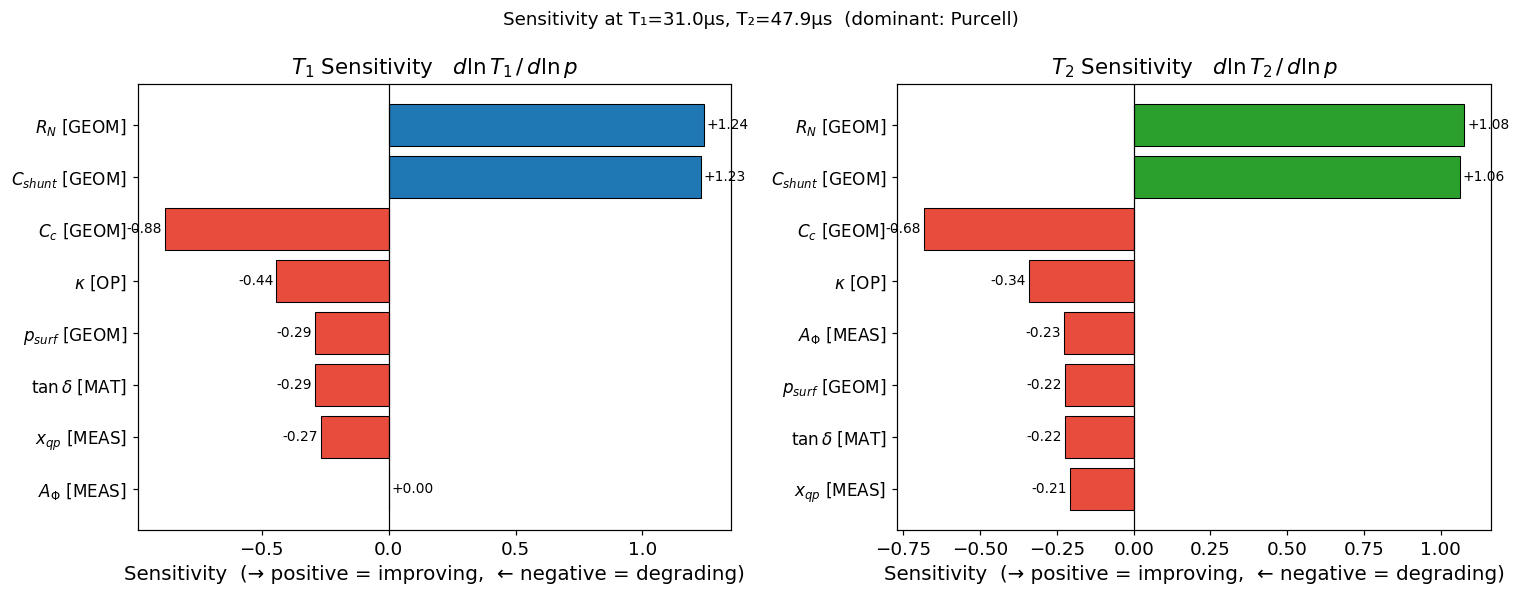

Saved: /Users/farukakbar/Downloads/files/sensitivity.png

Parameter                    S(T1)    S(T2)
─────────────────────────────────────────────
$R_N$ [GEOM]                +1.243   +1.076
$C_{shunt}$ [GEOM]          +1.233   +1.061
$C_c$ [GEOM]                -0.883   -0.682
$\kappa$ [OP]               -0.443   -0.342
$A_\Phi$ [MEAS]             +0.000   -0.228
$\tan\delta$ [MAT]          -0.291   -0.225
$p_{surf}$ [GEOM]           -0.291   -0.225
$x_{qp}$ [MEAS]             -0.267   -0.206


In [12]:
def compute_all(R_N_,C_shunt_,C_c_,kappa_,tan_delta_,p_surf_,x_qp_,A_flux_,flux_bias_):
    ej_   = np.pi*hbar*Delta_sc/(4*e**2*R_N_)    # Ambegaokar-Baratoff (tanh≈1 at 15mK)
    csig_ = C_J+C_shunt_
    ec_   = e**2/(2*csig_)
    om01_ = (np.sqrt(8*ej_*ec_)-ec_)/hbar
    dqr_  = om01_ - omega_r
    g_    = (C_c_/2)*np.sqrt(om01_*omega_r/(csig_*C_r))
    chi_  = g_**2/dqr_
    gP_   = (g_/dqr_)**2*kappa_
    gT_   = p_surf_*om01_*tan_delta_
    gQ_   = (8*ej_/(np.pi*hbar))*np.sqrt(2*Delta_sc/(hbar*om01_))*x_qp_
    G1_   = gP_+gT_+gQ_
    dEJ_  = -np.pi*ej_*np.sin(np.pi*flux_bias_)/Phi0
    dwEJ_ = np.sqrt(2*ec_/ej_)/(2*hbar)
    nth_  = 1/(np.exp(hbar*omega_r/(kB*T_fridge))-1)
    gfl_  = abs(dwEJ_*dEJ_)*A_flux_*np.sqrt(2*np.log(2))
    gph_  = 8*chi_**2*nth_/kappa_
    return 1/G1_, 1/(G1_/2+gfl_+gph_)

T1_0,T2_0=compute_all(R_N,C_shunt,C_c,kappa,tan_delta,p_surf,x_qp,A_flux,flux_bias_fraction)

param_fns={
    '$R_N$ [GEOM]'       :lambda d:compute_all(R_N*d,    C_shunt,   C_c,   kappa,   tan_delta,   p_surf,   x_qp,   A_flux,   flux_bias_fraction),
    '$C_{shunt}$ [GEOM]' :lambda d:compute_all(R_N,      C_shunt*d, C_c,   kappa,   tan_delta,   p_surf,   x_qp,   A_flux,   flux_bias_fraction),
    '$C_c$ [GEOM]'       :lambda d:compute_all(R_N,      C_shunt,   C_c*d, kappa,   tan_delta,   p_surf,   x_qp,   A_flux,   flux_bias_fraction),
    '$\\kappa$ [OP]'      :lambda d:compute_all(R_N,      C_shunt,   C_c,   kappa*d, tan_delta,   p_surf,   x_qp,   A_flux,   flux_bias_fraction),
    '$\\tan\\delta$ [MAT]':lambda d:compute_all(R_N,      C_shunt,   C_c,   kappa,   tan_delta*d, p_surf,   x_qp,   A_flux,   flux_bias_fraction),
    '$p_{surf}$ [GEOM]'  :lambda d:compute_all(R_N,      C_shunt,   C_c,   kappa,   tan_delta,   p_surf*d, x_qp,   A_flux,   flux_bias_fraction),
    '$x_{qp}$ [MEAS]'    :lambda d:compute_all(R_N,      C_shunt,   C_c,   kappa,   tan_delta,   p_surf,   x_qp*d, A_flux,   flux_bias_fraction),
    '$A_\\Phi$ [MEAS]'    :lambda d:compute_all(R_N,      C_shunt,   C_c,   kappa,   tan_delta,   p_surf,   x_qp,   A_flux*d, flux_bias_fraction),
}

delta=0.10
sens_T1,sens_T2,names=[],[],[]
for name,fn in param_fns.items():
    t1p,t2p=fn(1+delta); t1m,t2m=fn(1-delta)
    sens_T1.append((t1p-t1m)/(2*delta*T1_0))
    sens_T2.append((t2p-t2m)/(2*delta*T2_0))
    names.append(name)

fig,axes=plt.subplots(1,2,figsize=(14,5.5))
for ax,sens,title,bc in zip(axes,[sens_T1,sens_T2],
        ['$T_1$ Sensitivity   $d\\ln T_1\\,/\\,d\\ln p$',
         '$T_2$ Sensitivity   $d\\ln T_2\\,/\\,d\\ln p$'],['C0','C2']):
    idx=np.argsort(np.abs(sens))[::-1]
    sv=np.array(sens)[idx]; nl=np.array(names)[idx]
    bcols=[bc if s>=0 else '#e74c3c' for s in sv]
    ax.barh(range(len(sv)),sv,color=bcols,edgecolor='k',lw=0.7)
    ax.set_yticks(range(len(sv))); ax.set_yticklabels(nl,fontsize=11)
    ax.axvline(0,color='k',lw=0.8)
    ax.set_xlabel('Sensitivity  (→ positive = improving,  ← negative = degrading)')
    ax.set_title(title); ax.invert_yaxis()
    for i,s in enumerate(sv):
        ax.text(s+0.01*np.sign(s) if s!=0 else 0.01,i,f'{s:+.2f}',
                va='center',fontsize=9,ha='left' if s>=0 else 'right')

plt.suptitle(f'Sensitivity at T₁={T1_0*1e6:.1f}μs, T₂={T2_0*1e6:.1f}μs  '
             f'(dominant: {dominant})',fontsize=12)
plt.tight_layout()
savepath2=os.path.join(OUTDIR,'sensitivity.png')
plt.savefig(savepath2,bbox_inches='tight',dpi=130)
plt.show()
print(f'Saved: {savepath2}')

print(f'\n{"Parameter":<25} {"S(T1)":>8} {"S(T2)":>8}')
print('─'*45)
for n,s1,s2 in sorted(zip(names,sens_T1,sens_T2),key=lambda x:-abs(x[2])):
    print(f'{n:<25} {s1:>+8.3f} {s2:>+8.3f}')